In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob


# offline R2 visualization

In this notebook, we show how we generate r2 plot, i.e., Figure F3 in "Stable Machine-Learning Parameterization of Subgrid Processes with Real Geography and Full-physics Emulation", Hu et al. 2024, arXiv preprint:2306.08754.

## Set data path

All the simulation output, saved model weights, and preprocessed data used in Hu et al. 2024 "Stable Machine-Learning Parameterization of Subgrid Processes with Real Geography and Full-physics Emulation" are provided at zenodo (https://zenodo.org/records/12797810) that you can download. Please change the following path to your path that contains all downloaded folders.

In [2]:
data_path = '/global/homes/z/zeyuanhu/scratch/hu_etal2024_data_v2/'

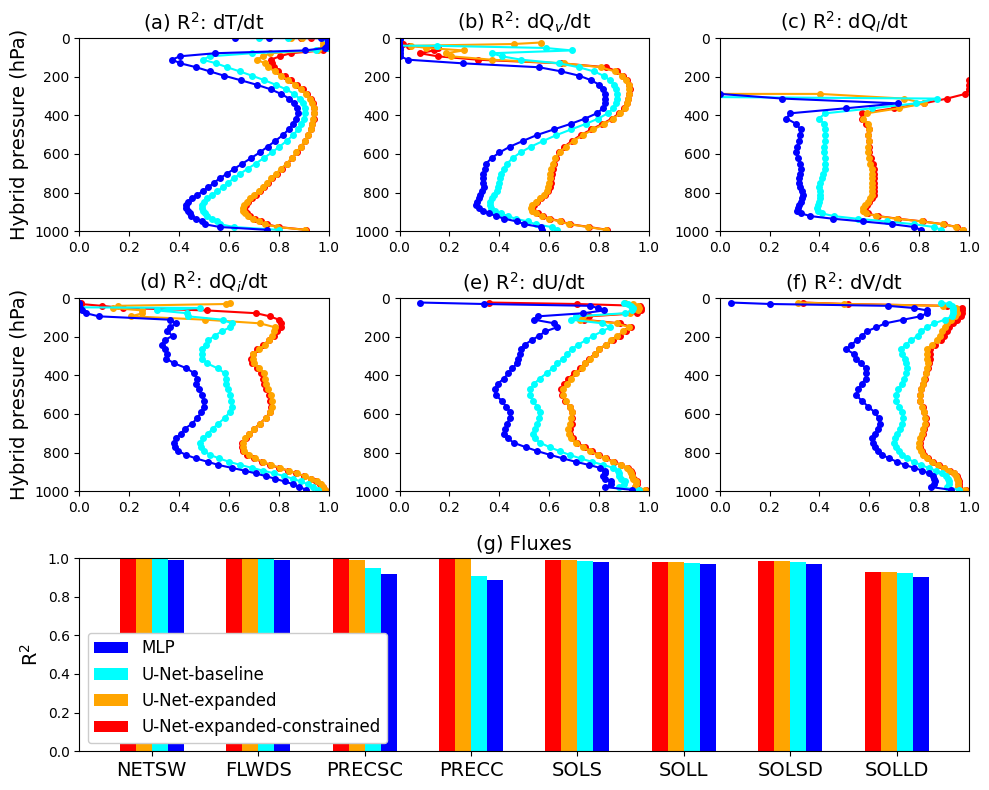

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
r2_v5_unet = np.load(data_path+'data/r2/r2-v5_unet_nonaggressive_cliprh_huber_rop2_r2.npy')
r2_v4_unet = np.load(data_path+'data/r2/r2-v4plus_unet_nonaggressive_cliprh_huber.npy')
r2_v2_unet = np.load(data_path+'data/r2/r2-v2rh_unet_nonaggressive_cliprh_huber_rop2.npy')
r2_mlp = np.load(data_path+'data/r2/r2-v2rh_mlp_nonaggressive_cliprh_huber_rop_3l_lr1em3_r2.npy')

ds = xr.open_dataset(data_path+'data/data_grid/E3SM_ML.GNUGPU.F2010-MMF1.ne4pg2_ne4pg2.eam.h0.0001-01.nc')
level = ds.lev.values

# Prepare data for the 2x3 panel plot
num_features_per_variable = 60
num_variables = 6  # Assuming 6 main variables dT/dt, dQv/dt, etc.
data_v5 = r2_v5_unet[:360].reshape((num_variables, num_features_per_variable))
data_v4 = r2_v4_unet[:360].reshape((num_variables, num_features_per_variable))
data_v2 = r2_v2_unet[:360].reshape((num_variables, num_features_per_variable))
data_mlp = r2_mlp[:360].reshape((num_variables, num_features_per_variable))

# Prepare data for the bar plot
last_8_v5 = r2_v5_unet[-8:]
last_8_v4 = r2_v4_unet[-8:]
last_8_v2 = r2_v2_unet[-8:]
last_8_mlp = r2_mlp[-8:]
x_labels = ["NETSW", "FLWDS", "PRECSC", "PRECC", "SOLS", "SOLL", "SOLSD", "SOLLD"]

# Define vertical levels (example data; replace with actual if available)

# Create a combined figure
fig = plt.figure(figsize=(10, 8))

# Create 2x3 panel plots
for i in range(num_variables):
    ax = fig.add_subplot(3, 3, i + 1)
    ax.plot(data_v5[i], level, linestyle='-', marker='o', color='red', label='Unet + expanded inputs + physics constraints', linewidth=1.5, markersize=4)
    ax.plot(data_v4[i], level, linestyle='-', marker='o', color='orange', label='Unet + expanded inputs', linewidth=1.5, markersize=4)
    ax.plot(data_v2[i], level, linestyle='-', marker='o', color='cyan', label='Unet', linewidth=1.5, markersize=4)
    ax.plot(data_mlp[i], level, linestyle='-', marker='o', color='blue', label='MLP', linewidth=1.5, markersize=4)
    ax.set_title(f"{['(a) R$^2$: dT/dt', '(b) R$^2$: dQ$_v$/dt', '(c) R$^2$: dQ$_l$/dt', '(d) R$^2$: dQ$_i$/dt', '(e) R$^2$: dU/dt', '(f) R$^2$: dV/dt'][i]}", fontsize=14)
    ax.set_ylim(1000,0)
    ax.set_xlim(0, 1)
    ax.set_xlabel('')
    # if i < 3:
    #     ax.set_xlabel('')
    # else:
    #     ax.set_xlabel('$R^2$ Score', fontsize=14)
    if i in [0,3]:
        ax.set_ylabel('Hybrid pressure (hPa)', fontsize=14)
    else:
        ax.set_ylabel('')

# Create bar plot
ax = fig.add_subplot(3, 1, 3)
x = np.arange(len(x_labels))
bar_width = 0.15
ax.bar(x - 1.5 * bar_width, last_8_v5, bar_width, color='red', label='U-Net-expanded-constrained')
ax.bar(x - 0.5 * bar_width, last_8_v4, bar_width, color='orange', label='U-Net-expanded')
ax.bar(x + 0.5 * bar_width, last_8_v2, bar_width, color='cyan', label='U-Net-baseline')
ax.bar(x + 1.5 * bar_width, last_8_mlp, bar_width, color='blue', label='MLP')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=14)
ax.set_ylabel('R$^2$', fontsize=14)
ax.set_title('(g) Fluxes', fontsize=14)
ax.set_ylim(0, 1)
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), fontsize=12, loc='lower left', framealpha=1)

# ax.legend(fontsize=12, loc='lower left', framealpha=1)

# Adjust layout
plt.tight_layout()
# plt.savefig('r2-transposed.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()